The aim is to understand the most influential users in the iNaturalist community.

In [1]:
from collections import defaultdict
import matplotlib.cm as cm
import json
import itertools
import pandas as pd
import networkx as nx
import numpy as np
import math
import os
import matplotlib.pyplot as plt
import scipy.stats
from datetime import datetime
from collections import defaultdict
import networkx as nx
import community as community_louvain

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Data Loading and Initial Cleaning

In [3]:
city_years = {
 'Sri_Lanka':[2016,2017,2018,2019,2020,2021,2022,2023],
}

In [4]:
path = '/Users/zahrafarook/Desktop/DataAnalysis/data/Sri_Lanka/Colombo'
dir_list = os.listdir(path)
print(dir_list)

['colombo_user_profile_all.xlsx', 'Bioblitz .ipynb', '.DS_Store', 'colombo_bioblitz_unique_users.csv', 'Colombo_Sri_Lanka_2023.csv', 'Colombo_Sri_Lanka_2022.csv', 'usergroups.csv', 'Colombo_Sri_Lanka_2020.csv', 'observations_colombo.csv', 'Colombo_Sri_Lanka_2021.csv', 'Colombo_Sri_Lanka_2019.csv', 'Colombo_Sri_Lanka_2018.csv', 'Colombo_Sri_Lanka_2016.csv', 'Colombo_Sri_Lanka_2017.csv', 'usergroupsall.xlsx', 'user_data_with_links_all.xlsx', '.ipynb_checkpoints', 'Colombo_user_profile_all_final.xlsx', 'colombo_bioblitz_profile_all.xlsx', 'observations.csv', 'usergroups.xlsx']


In [5]:
dfs = defaultdict(dict)
dfall = []


for city, years in city_years.items():
    for year in years:
        print("Loading: ", city, year)

        df = pd.read_csv("/Users/zahrafarook/Desktop/DataAnalysis/data/Sri_Lanka/Colombo/Colombo_{}_{}.csv".format(city, year))
        dfs[city][year] = df
        dfall.append(df)

dfall = pd.concat(dfall)
dfs['Sri_Lanka'][2016].head()

Loading:  Sri_Lanka 2016
Loading:  Sri_Lanka 2017
Loading:  Sri_Lanka 2018
Loading:  Sri_Lanka 2019
Loading:  Sri_Lanka 2020
Loading:  Sri_Lanka 2021
Loading:  Sri_Lanka 2022
Loading:  Sri_Lanka 2023


,id,observed_on_string,observed_on,time_observed_at,created_time_zone,created_at,updated_at,description,user_id,quality_grade,...,preferred_common_name,iconic_taxon_name,taxon_rank,taxon_parent_id,taxon_native,taxon_endemic,taxon_threatened,taxon_search_rank,taxon_observations,identifications
0,2816203,2016-01-02,2016-01-02,NaN,Pacific/Honolulu,2016-03-22T01:17:02-10:00,2022-05-17T05:02:31-10:00,GLYPHODES BIVITRALIS \r\nGlyphodes bivitralis ...,52446,research,...,NaN,Insecta,species,124281,True,False,False,657,657,"[{'user_id': 52446, 'category': 'improving', '..."
1,2816208,2016-01-27,2016-01-27,NaN,Pacific/Honolulu,2016-03-22T01:29:44-10:00,2024-06-20T14:47:22-10:00,"Epicrocis sp.\r\n Pyralidae, Phycitinae",52446,needs_id,...,NaN,Insecta,genus,122926,False,False,False,587,587,"[{'user_id': 52446, 'category': 'improving', '..."
2,3631812,2016/07/06 3:19 AM HST,2016-07-06,2016-07-06T03:19:00-10:00,Pacific/Honolulu,2016-07-06T03:46:41-10:00,2019-01-10T02:03:02-10:00,Caterpillar feeds on Ixora coccinea (Rubiaceae),52446,needs_id,...,NaN,Insecta,genus,124038,False,False,False,960,960,"[{'user_id': 8828, 'category': 'improving', 'd..."
3,3653029,2016/07/10 2:50 PM +0530,2016-07-10,2016-07-10T14:50:00+05:30,Asia/Kolkata,2016-07-10T14:53:13+05:30,2024-06-24T04:04:36+05:30,Achrosis sp.\nAchrosis is a genus of moth in t...,52446,needs_id,...,NaN,Insecta,genus,124038,False,False,False,960,960,"[{'user_id': 52446, 'category': 'improving', '..."
4,3659537,2016/07/11 1:12 AM HST,2016-07-11,2016-07-11T01:12:00-10:00,Pacific/Honolulu,2016-07-11T01:24:50-10:00,2024-06-23T12:32:48-10:00,NaN,52446,needs_id,...,NaN,Insecta,tribe,48847,False,False,False,38880,38880,"[{'user_id': 52446, 'category': 'leading', 'di..."


In [8]:
dfall

,id,observed_on_string,observed_on,time_observed_at,created_time_zone,created_at,updated_at,description,user_id,quality_grade,...,preferred_common_name,iconic_taxon_name,taxon_rank,taxon_parent_id,taxon_native,taxon_endemic,taxon_threatened,taxon_search_rank,taxon_observations,identifications
0,2816203,2016-01-02,2016-01-02,NaN,Pacific/Honolulu,2016-03-22T01:17:02-10:00,2022-05-17T05:02:31-10:00,GLYPHODES BIVITRALIS \r\nGlyphodes bivitralis ...,52446,research,...,NaN,Insecta,species,124281.0,True,False,False,657.0,657.0,"[{'user_id': 52446, 'category': 'improving', '..."
1,2816208,2016-01-27,2016-01-27,NaN,Pacific/Honolulu,2016-03-22T01:29:44-10:00,2024-06-20T14:47:22-10:00,"Epicrocis sp.\r\n Pyralidae, Phycitinae",52446,needs_id,...,NaN,Insecta,genus,122926.0,False,False,False,587.0,587.0,"[{'user_id': 52446, 'category': 'improving', '..."
2,3631812,2016/07/06 3:19 AM HST,2016-07-06,2016-07-06T03:19:00-10:00,Pacific/Honolulu,2016-07-06T03:46:41-10:00,2019-01-10T02:03:02-10:00,Caterpillar feeds on Ixora coccinea (Rubiaceae),52446,needs_id,...,NaN,Insecta,genus,124038.0,False,False,False,960.0,960.0,"[{'user_id': 8828, 'category': 'improving', 'd..."
3,3653029,2016/07/10 2:50 PM +0530,2016-07-10,2016-07-10T14:50:00+05:30,Asia/Kolkata,2016-07-10T14:53:13+05:30,2024-06-24T04:04:36+05:30,Achrosis sp.\nAchrosis is a genus of moth in t...,52446,needs_id,...,NaN,Insecta,genus,124038.0,False,False,False,960.0,960.0,"[{'user_id': 52446, 'category': 'improving', '..."
4,3659537,2016/07/11 1:12 AM HST,2016-07-11,2016-07-11T01:12:00-10:00,Pacific/Honolulu,2016-07-11T01:24:50-10:00,2024-06-23T12:32:48-10:00,NaN,52446,needs_id,...,NaN,Insecta,tribe,48847.0,False,False,False,38880.0,38880.0,"[{'user_id': 52446, 'category': 'leading', 'di..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2279,223735231,2023/03/19 4:14 PM,2023-03-19,2023-03-19T16:14:00+05:30,Asia/Colombo,2024-06-19T17:58:49+05:30,2024-06-19T19:48:16+05:30,NaN,8269917,research,...,sandalwood defoliator,Insecta,species,57490.0,False,False,False,2026.0,2026.0,"[{'user_id': 8269917, 'category': 'improving',..."
2280,223780810,2023/09/30 12:36 PM,2023-09-30,2023-09-30T12:36:00+05:30,Asia/Colombo,2024-06-19T21:53:56+05:30,2024-06-19T22:24:53+05:30,NaN,8269917,research,...,Seven-spotted Handmaiden Moth,Insecta,species,57490.0,False,False,False,1048.0,1048.0,"[{'user_id': 8269917, 'category': 'improving',..."
2281,223912229,2023-04-30 10:27:55,2023-04-30,2023-04-30T10:27:55+05:30,Asia/Colombo,2024-06-20T09:52:52+05:30,2024-06-20T10:24:32+05:30,NaN,6581117,research,...,Asian Sapphire Flutterer,Insecta,species,82002.0,False,False,False,856.0,856.0,"[{'user_id': 6581117, 'category': 'improving',..."
2282,223970278,2023-12-04 15:04:47,2023-12-04,2023-12-04T15:04:47+05:30,Asia/Colombo,2024-06-20T19:08:38+05:30,2024-06-21T13:39:27+05:30,NaN,8127063,research,...,Common Hourglass Tree Frog,Amphibia,species,26549.0,True,True,False,268.0,268.0,"[{'user_id': 8127063, 'category': 'improving',..."


In [12]:
len(dfall['user_id'].value_counts())

717

## Bipartite Network Construction and Weighting


<p> we construct the Bipartite Network (bipartite_G) which represents the relationship between Identifiers ('action' nodes) and Observations ('observation' nodes)</p>

In [13]:
def bipartite_net_make(df, min_weight=2):
    edge_list = []
    df_valid = df[df['identifications'].notnull()].copy()

    for index, row in df_valid.iterrows():
        idents_str = row['identifications']
        
        parsed_data = None
        try:
            
            parsed_data = json.loads(idents_str)
        except json.JSONDecodeError:
            try:
     
                parsed_data = eval(idents_str) 
            except:
                
                continue
        if parsed_data:
            target_user = row['user_id']
            
            for ident in parsed_data:
                action_maker = ident.get('user_id')
                if action_maker is not None:
                    edge_list.append((action_maker, target_user))
  

    # Create the initial edges DataFrame 
    edges = pd.DataFrame(edge_list, columns=['user_id', 'target'])
        
    # Remove loops (user identified their own observation)
    edges = edges[edges['user_id'] != edges['target']].copy()
    
    # Count the edges (weight) 
    edges['weight'] = 1
    edges = edges.groupby(by=['user_id', 'target']).sum().reset_index()
    edges = edges[edges['weight'] >= min_weight].copy()
        
    # Apply type prefixing for bipartite identification
    edges['source_node'] = 'I' + edges['user_id'].astype(str) # I for Identifier/Action
    edges['target_node'] = 'C' + edges['target'].astype(str)   # C for Creator/Observation
    
    # Create the graph directly from the edge list
    bipartite_G = nx.from_pandas_edgelist(
        edges,
        source='source_node',
        target='target_node',
        edge_attr='weight',
        create_using=nx.Graph()
    )
    
    # Add bipartite attributes to nodes 
    action_nodes = edges['source_node'].unique()
    obs_nodes = edges['target_node'].unique()
    
    for node in action_nodes:
        bipartite_G.nodes[node]['bipartite'] = 'action'
    for node in obs_nodes:
        bipartite_G.nodes[node]['bipartite'] = 'observation'
        
    return bipartite_G

# bipartite_G = bipartite_net_make(dfall, min_weight = 2)

## Here we create two types of projections.
1.projection without weight. this is a simple count projection (baseline)- 
simple COUNT of shared observations. This is the simplest projection. It only checks if a shared observation exists. It ignores any weights which might have on the bipartite edges.<br>
2. projection with custom weight - This custom function uses the bipartite edge weights and sums them up . The final edge weight reflects the total cumulative shared by the two users(indentifiers).

using the Simple count projection network and the custom weighted projection Network, we turn the two-mode (bipartite) data into a one-mode (unipartite) network of Identifier users, and measuring the strength of the connection.

In [14]:
# Existence of a shared 
def projection_make(bip_net, projection = 'action'):
    """
    The function returns a projection of a bipartite network 
    
    Arguments:
    
    - bip_net -- bipartite networks
    - projection (observation or action) -- in the case of 'action', the function returns a network where users are
    connected based on the common observations (they were working on); 'observation'  returns a network of 
    observations having a common list of collaborators
    """
   
    # Verifying the bipartite attribute
    assert all('bipartite' in bip_net.nodes[n] for n in bip_net.nodes()), "Bipartite attribute missing in nodes"

    if projection == 'action':
        action_nodes = [node for node in bip_net.nodes() if bip_net.nodes[node]['bipartite'] == 'action']
        actions_graph = nx.bipartite.projection.projected_graph(bip_net, action_nodes)
        
        return actions_graph
    
    elif projection == 'observation':
        observation_nodes = [node for node in bip_net.nodes() if bip_net.nodes[node]['bipartite'] == 'observation']
        observations_graph = nx.bipartite.projection.projected_graph(bip_net, observation_nodes)
    
    else:
        return observations_graph

In [50]:
## to be removed. this function doesn't sum up the common obs count.

def projection_make_weight(bip_net, projection='action'):
    """
    The function returns a weighted projection of a bipartite network.
    Adds a 'weight' attribute to each edge.
    The weight = number of common observations identified by the two users.

    Arguments:
    - bip_net -- bipartite network
    - projection (str: 'action' or 'observation') -- 
      - 'action': returns a user–user network (identifiers) where users are connected if they identified the same observations.
      - 'observation': returns an observation–observation network where observations are connected if they share the same identifiers.
    """
    # check all nodes have the bipartite attribute
    assert all('bipartite' in bip_net.nodes[n] for n in bip_net.nodes()), "Bipartite attribute missing in nodes"

    if projection == 'action':
        action_nodes = [node for node in bip_net.nodes() if bip_net.nodes[node]['bipartite'] == 'action']
        actions_graph = nx.bipartite.weighted_projected_graph(bip_net, action_nodes)
        return actions_graph

    elif projection == 'observation':
        observation_nodes = [node for node in bip_net.nodes() if bip_net.nodes[node]['bipartite'] == 'observation']
        observations_graph = nx.bipartite.weighted_projected_graph(bip_net, observation_nodes)
        return observations_graph

    else:
        raise ValueError("Projection must be either 'action' or 'observation'")


This custom function uses the bipartite edge weights and sums them up . The final edge weight reflects the total cumulative shared by the two users(indentifiers).

In [16]:
# Frequency/Intensity of the shared
def projection_custom_weight(bip_net, nodes_to_project, node_type_to_project):
    """
    Manually creates a weighted projection of a bipartite network.
    The weight of an edge between two nodes U and V in the projected graph
    is the sum of the weights of their connections to common neighbors
    in the bipartite graph.

    Arguments:
    - bip_net -- The bipartite graph.
    - nodes_to_project -- An iterable of nodes of the same bipartite type
                          (e.g., all 'action' nodes or all 'observation' nodes).
    - node_type_to_project (str) -- 'action' or 'observation', indicating which set of nodes is being projected.
                                    Used to correctly identify common neighbors' type.
    """
    projected_graph = nx.Graph()
    projected_graph.add_nodes_from(nodes_to_project)

    # Determine the type of the common neighbors
    # If projecting 'action' nodes, common neighbors are 'observation' nodes
    # If projecting 'observation' nodes, common neighbors are 'action' nodes
    common_neighbor_bipartite_type = 'observation' if node_type_to_project == 'action' else 'action'

    # Iterate over all pairs of nodes within the set to project
    nodes_list = list(nodes_to_project) # Convert to list for indexing
    for i, u in enumerate(nodes_list):
        for v in nodes_list[i+1:]: # Avoid self-loops and duplicate pairs
            common_neighbors = [n for n in nx.common_neighbors(bip_net, u, v)
                                if bip_net.nodes[n].get('bipartite') == common_neighbor_bipartite_type]

            edge_weight_sum = 0
            if common_neighbors:
                for n in common_neighbors:
                    # Sum the weights of the edges from u to n and from v to n in the bipartite graph
                    # This is how we want to aggregate the strength of shared connections
                    weight_u_n = bip_net[u][n].get('weight', 0)
                    weight_v_n = bip_net[v][n].get('weight', 0)
                    edge_weight_sum += (weight_u_n + weight_v_n)

                if edge_weight_sum > 0:
                    projected_graph.add_edge(u, v, weight=edge_weight_sum)
    return projected_graph

In [17]:
def descriptive_net_analysis(net):

    """
    The function returns basic descriptive characteristics of a net
    """

    nodes = net.number_of_nodes()
    edges = net.number_of_edges()
    density = nx.density(net)

    beetweenness = nx.betweenness_centrality(net)
    avg_beetw = np.mean(list(beetweenness.values()))
    sd_beetw = np.std(list(beetweenness.values()))

    degree = nx.degree_centrality(net)
    avg_degree = np.mean(list(degree.values()))
    sd_degree = np.std(list(degree.values()))

    clustering_coef = nx.average_clustering(net)

    return {'number of nodes': nodes, 'number of edges': edges, 'density': density, 'average beetweenness': avg_beetw, 'sd_beetw': sd_beetw, 'average degree': avg_degree, 'sd_degree': sd_degree, 'clustering coefficient': clustering_coef}

    print("number of nodes: {}, number of edges: {}".format(nodes, edges))
    print("density of the network: {0:.2f}".format(density))
    print("average beetweenness of the network: {}, sd: {}".format(avg_beetw, sd_beetw))
    print("average degree of the network: {}, sd: {}".format(avg_degree, sd_degree))
    print("clustering coefficient:", clustering_coef)

## Construction of networks


In [41]:
#bipartite
bipartite_G = bipartite_net_make(dfall, min_weight = 2)

In [42]:
print("\nChecking weights in bipartite_G:")
bip_edge_count = 0
all_bip_weights_are_one = True
for u, v, data in bipartite_G.edges(data=True):
    current_weight = data.get('weight', 1)
    print(f"Bipartite edge: ({u}, {v}, weight={current_weight})")
    if current_weight != 1:
        all_bip_weights_are_one = False
    bip_edge_count += 1
    if bip_edge_count > 10: # Print only a few
        break
print(f"Total edges in bipartite_G: {bipartite_G.number_of_edges()}")
if all_bip_weights_are_one and bip_edge_count > 0:
    print("WARNING: All sampled edges in bipartite_G have weight=1. This will result in unweighted projection unless your data truly has no repeated identifications.")


Checking weights in bipartite_G:
Bipartite edge: (I28, C2770057, weight=4)
Bipartite edge: (C2770057, I8828, weight=8)
Bipartite edge: (C2770057, I11700, weight=2)
Bipartite edge: (C2770057, I56488, weight=14)
Bipartite edge: (C2770057, I67428, weight=8)
Bipartite edge: (C2770057, I180811, weight=3)
Bipartite edge: (C2770057, I279977, weight=5)
Bipartite edge: (C2770057, I440756, weight=2)
Bipartite edge: (C2770057, I476404, weight=2)
Bipartite edge: (C2770057, I730065, weight=2)
Bipartite edge: (C2770057, I792319, weight=2)
Total edges in bipartite_G: 3465


In [48]:
#projection for weight
colombo = projection_make(bipartite_G, projection = 'action')

In [49]:
#test
for u, v, d in colombo.edges(data=True):
    print(f"Edge ({u}, {v}) weight:", d.get('weight', 1))


Edge (I28, I180811) weight: 1
Edge (I28, I3744951) weight: 1
Edge (I28, I960916) weight: 1
Edge (I28, I11700) weight: 1
Edge (I28, I8828) weight: 1
Edge (I28, I1208365) weight: 1
Edge (I28, I2538017) weight: 1
Edge (I28, I476404) weight: 1
Edge (I28, I2408849) weight: 1
Edge (I28, I4317325) weight: 1
Edge (I28, I730065) weight: 1
Edge (I28, I56488) weight: 1
Edge (I28, I792319) weight: 1
Edge (I28, I1548062) weight: 1
Edge (I28, I1013268) weight: 1
Edge (I28, I1790012) weight: 1
Edge (I28, I2195034) weight: 1
Edge (I28, I279977) weight: 1
Edge (I28, I67428) weight: 1
Edge (I28, I440756) weight: 1
Edge (I28, I2406841) weight: 1
Edge (I28, I2723014) weight: 1
Edge (I28, I1578246) weight: 1
Edge (I28, I2742819) weight: 1
Edge (I305, I710151) weight: 1
Edge (I305, I1128020) weight: 1
Edge (I305, I26642) weight: 1
Edge (I305, I180811) weight: 1
Edge (I305, I2376835) weight: 1
Edge (I305, I701243) weight: 1
Edge (I305, I11700) weight: 1
Edge (I305, I5643) weight: 1
Edge (I305, I8828) weight:

###  hypothesis 
1. Users who are most influential (highest weighted degree) in the projected network will show the highest betweenness centrality in that same network.
2. 



In [21]:
#identifier -identifier netowrk, using custom weight function
action_nodes_to_project = [node for node in bipartite_G.nodes() if bipartite_G.nodes[node]['bipartite'] == 'action']
iden_iden_G = projection_make_weight(bipartite_G, action_nodes_to_project, 'action')


In [22]:
#Verify the projected graph's weights
print(f"\nNumber of nodes in colombo: {iden_iden_G.number_of_nodes()}")
print(f"Number of edges in colombo: {iden_iden_G.number_of_edges()}")
print("Sample edges from colombo (u, v, weight):")
count = 0
for u, v, data in iden_iden_G.edges(data=True):
    print(f"({u}, {v}, {data.get('weight', 'No weight attribute!')})")
    count += 1
    if count > 10: # Print only the first 10 for brevity
        break
if count == 0:
    print("No edges found in colombo!")


Number of nodes in colombo: 552
Number of edges in colombo: 32135
Sample edges from colombo (u, v, weight):
(I28, I8828, 12)
(I28, I11700, 6)
(I28, I56488, 18)
(I28, I67428, 12)
(I28, I180811, 7)
(I28, I279977, 9)
(I28, I440756, 6)
(I28, I476404, 6)
(I28, I730065, 6)
(I28, I792319, 6)
(I28, I960916, 7)


In [51]:
print("network for Colombo Sri Lanka")
print('-----------------------------')
descriptive_net_analysis(colombo)

network for Colombo Sri Lanka
-----------------------------


{'number of nodes': 552,
 'number of edges': 32135,
 'density': 0.21130881927457323,
 'average beetweenness': 0.0014239291837334933,
 'sd_beetw': 0.00550181776898863,
 'average degree': 0.21130881927457323,
 'sd_degree': 0.18745388877782881,
 'clustering coefficient': 0.8578184077569136}

## create nodes and edges for simple weight network. weight = 1. Edges exist if two uses shared one observation

In [52]:
# Creating nodes df with only 'identifier'
nodes_df = pd.DataFrame({
    'id': list(colombo.nodes()),
    'label': [str(n) for n in colombo.nodes()],
    'type': 'identifier'  # all nodes are identifiers/helpers in this projection
})

# edges df with weights (default 1 if weight not found)
edges_df = pd.DataFrame([
    (u, v, d.get('weight', 1)) for u, v, d in colombo.edges(data=True)
], columns=['source', 'target', 'weight'])

#save
nodes_df.to_csv('colombo_nodes.csv', index=False)
edges_df.to_csv('colombo_edges.csv', index=False)

In [53]:
print(nodes_df.columns)
print(nodes_df)

Index(['id', 'label', 'type'], dtype='object')
           id     label        type
0         I28       I28  identifier
1        I305      I305  identifier
2        I477      I477  identifier
3       I3376     I3376  identifier
4       I3785     I3785  identifier
..        ...       ...         ...
547  I7699943  I7699943  identifier
548  I7846972  I7846972  identifier
549  I7861044  I7861044  identifier
550  I7973031  I7973031  identifier
551  I8127063  I8127063  identifier

[552 rows x 3 columns]


In [54]:
print(edges_df.columns)
print(edges_df)

Index(['source', 'target', 'weight'], dtype='object')
         source    target  weight
0           I28   I180811       1
1           I28  I3744951       1
2           I28   I960916       1
3           I28    I11700       1
4           I28     I8828       1
...         ...       ...     ...
32130  I7564457  I7699943       1
32131  I7595241  I7654724       1
32132  I7650456  I7846972       1
32133  I7650456  I7654724       1
32134  I7654724  I7846972       1

[32135 rows x 3 columns]


## create nodes and edges for projected identifiers (user-user connection to see the influential users)

In [56]:
# Creating nodes df with only 'identifier'
iden_nodes_df = pd.DataFrame({
    'id': list(iden_iden_G.nodes()),
    'label': [str(n) for n in iden_iden_G.nodes()],
    'type': 'identifier'  # all nodes are identifiers/helpers in this projection
})

# edges df with weights (default 1 if weight not found)
iden_edges_df = pd.DataFrame([
    (u, v, d.get('weight', 1)) for u, v, d in iden_iden_G.edges(data=True)
], columns=['source', 'target', 'weight'])

#save
iden_nodes_df.to_csv('colombo_projected_identifier_nodes.csv', index=False)
iden_edges_df.to_csv('colombo_projected_identifier_edges.csv', index=False)

In [57]:
print(iden_nodes_df.columns)
print(iden_nodes_df)
print(iden_edges_df.columns)
print(iden_edges_df)

Index(['id', 'label', 'type'], dtype='object')
           id     label        type
0         I28       I28  identifier
1        I305      I305  identifier
2        I477      I477  identifier
3       I3376     I3376  identifier
4       I3785     I3785  identifier
..        ...       ...         ...
547  I7699943  I7699943  identifier
548  I7846972  I7846972  identifier
549  I7861044  I7861044  identifier
550  I7973031  I7973031  identifier
551  I8127063  I8127063  identifier

[552 rows x 3 columns]
Index(['source', 'target', 'weight'], dtype='object')
         source    target  weight
0           I28     I8828      12
1           I28    I11700       6
2           I28    I56488      18
3           I28    I67428      12
4           I28   I180811       7
...         ...       ...     ...
32130  I7564457  I7699943       8
32131  I7595241  I7654724       7
32132  I7650456  I7654724       4
32133  I7650456  I7846972       4
32134  I7654724  I7846972       4

[32135 rows x 3 columns]


## creating edges and nodes from bipartite graph

In [58]:
"""
two distinct node types — Identifiers (users who identify) and Observers (users who make observations). 
Edges connect identifiers to observers if an identifier identified an observation made by the observer.
The weight indicates how many times that identification happened between the two users.
"""

# Create df 
nodes_df = pd.DataFrame(list(bipartite_G.nodes(data=True)), columns=['node', 'attributes'])

# Assign node types - I or O
nodes_df['type'] = nodes_df['node'].apply(lambda x: 'identifier' if str(x).startswith('I') else 'observer')

# creating df (idfenfier and observer)
identifier_nodes = nodes_df[nodes_df['type'] == 'identifier']
observer_nodes = nodes_df[nodes_df['type'] == 'observer']

# Extract edges 
edges_raw = list(bipartite_G.edges(data=True))
edges_df = pd.DataFrame([
    {'source': u, 'target': v, 'weight': d.get('weight', 1)}  # default weight = 1 if missing
    for u, v, d in edges_raw
])

# Save to CSV
identifier_nodes.to_csv('identifier_nodes_colombo.csv', index=False)
observer_nodes.to_csv('observer_nodes_colombo.csv', index=False)
edges_df.to_csv('edges_colombo.csv', index=False)



# Centrality measures 

In [60]:
degree_centrality = nx.degree_centrality(colombo)
betweenness = nx.betweenness_centrality(colombo, weight='weight')
eigenvector = nx.eigenvector_centrality(colombo, weight='weight')

In [61]:
centrality_df = pd.DataFrame({
    'id': list(colombo.nodes()),
    'degree_centrality': [format(degree_centrality[n], '.8f') for n in colombo.nodes()],
    'betweenness': [format(betweenness[n], '.8f') for n in colombo.nodes()],
    'eigenvector': [format(eigenvector[n], '.8f') for n in colombo.nodes()]
})
centrality_df.to_csv('colombo_influential_users.csv', index=False)

# Louvain Community Detection

In [76]:
import networkx as nx
from networkx.algorithms.community import louvain_communities


# Get communities
communities = louvain_communities(iden_iden_G, weight='weight', resolution=1)

# Show communities
for i, com in enumerate(communities):
    print(f"Community {i+1}: {com}")


Community 1: {'I703773'}
Community 2: {'I827099'}
Community 3: {'I1505165'}
Community 4: {'I710151', 'I709244', 'I26642', 'I180811', 'I1103606', 'I1250773', 'I3719579', 'I701243', 'I300627', 'I4470469', 'I1567578', 'I4393858', 'I4923822', 'I3813240', 'I270365', 'I15030', 'I217057', 'I2538017', 'I785998', 'I724460', 'I2198757', 'I1230411', 'I3634948', 'I2152099', 'I2421332', 'I741615', 'I5643618', 'I171012', 'I713658', 'I2728712', 'I769610', 'I1722768', 'I742241', 'I1105519', 'I1607900', 'I44170', 'I42688', 'I792319', 'I4585159', 'I559151', 'I5244244', 'I646387', 'I1202015', 'I1821870', 'I629554', 'I1717105', 'I1124641', 'I4859', 'I1935877', 'I6038310', 'I2379040', 'I1243114', 'I4772269', 'I1020162', 'I1875062', 'I2723014', 'I5366668', 'I155951', 'I1947109', 'I2674854', 'I904914', 'I2722993', 'I399948', 'I1417816', 'I614374', 'I370367', 'I166761', 'I291552', 'I1405447', 'I473473', 'I161086', 'I2852333', 'I2540083', 'I143067', 'I121021', 'I5199891', 'I811913', 'I2667931', 'I8917', 'I5797

In [74]:
partition = community_louvain.best_partition(iden_iden_G)
partition

{'I28': 4,
 'I305': 1,
 'I477': 1,
 'I3376': 1,
 'I3785': 1,
 'I4079': 4,
 'I4502': 2,
 'I4859': 4,
 'I5043': 1,
 'I5643': 1,
 'I7757': 4,
 'I7943': 4,
 'I8060': 4,
 'I8828': 2,
 'I8917': 4,
 'I10787': 5,
 'I11060': 4,
 'I11700': 1,
 'I13444': 4,
 'I15030': 4,
 'I17378': 2,
 'I17623': 2,
 'I18222': 4,
 'I19073': 4,
 'I26642': 4,
 'I28258': 2,
 'I29392': 5,
 'I30342': 2,
 'I31576': 4,
 'I33609': 2,
 'I37608': 5,
 'I42688': 4,
 'I44170': 4,
 'I47594': 4,
 'I50920': 1,
 'I56488': 4,
 'I56848': 5,
 'I59227': 4,
 'I59233': 2,
 'I63043': 4,
 'I67428': 1,
 'I72671': 4,
 'I84719': 2,
 'I85295': 2,
 'I97044': 4,
 'I97992': 1,
 'I98904': 4,
 'I108966': 2,
 'I121021': 4,
 'I140956': 4,
 'I143067': 4,
 'I147592': 4,
 'I150938': 4,
 'I155951': 4,
 'I161086': 4,
 'I165078': 4,
 'I166761': 4,
 'I169070': 4,
 'I171012': 4,
 'I175865': 1,
 'I180811': 4,
 'I212804': 5,
 'I217057': 4,
 'I217955': 5,
 'I220795': 4,
 'I222137': 4,
 'I233217': 4,
 'I242224': 1,
 'I264861': 1,
 'I269952': 4,
 'I270365': 4,
 

In [78]:
# Compute the best partition (community detection)
partition = community_louvain.best_partition(iden_iden_G)


In [77]:
#  get modularity score
modularity = community_louvain.modularity(partition, iden_iden_G)
print("Modularity:", modularity)


Modularity: 0.12126963181538965



Number of nodes in colombo: 552
Number of edges in colombo: 32135
Size of largest connected component: 547 nodes
Number of edges in largest connected component: 32135
Louvain partition found 3 communities in the largest component.


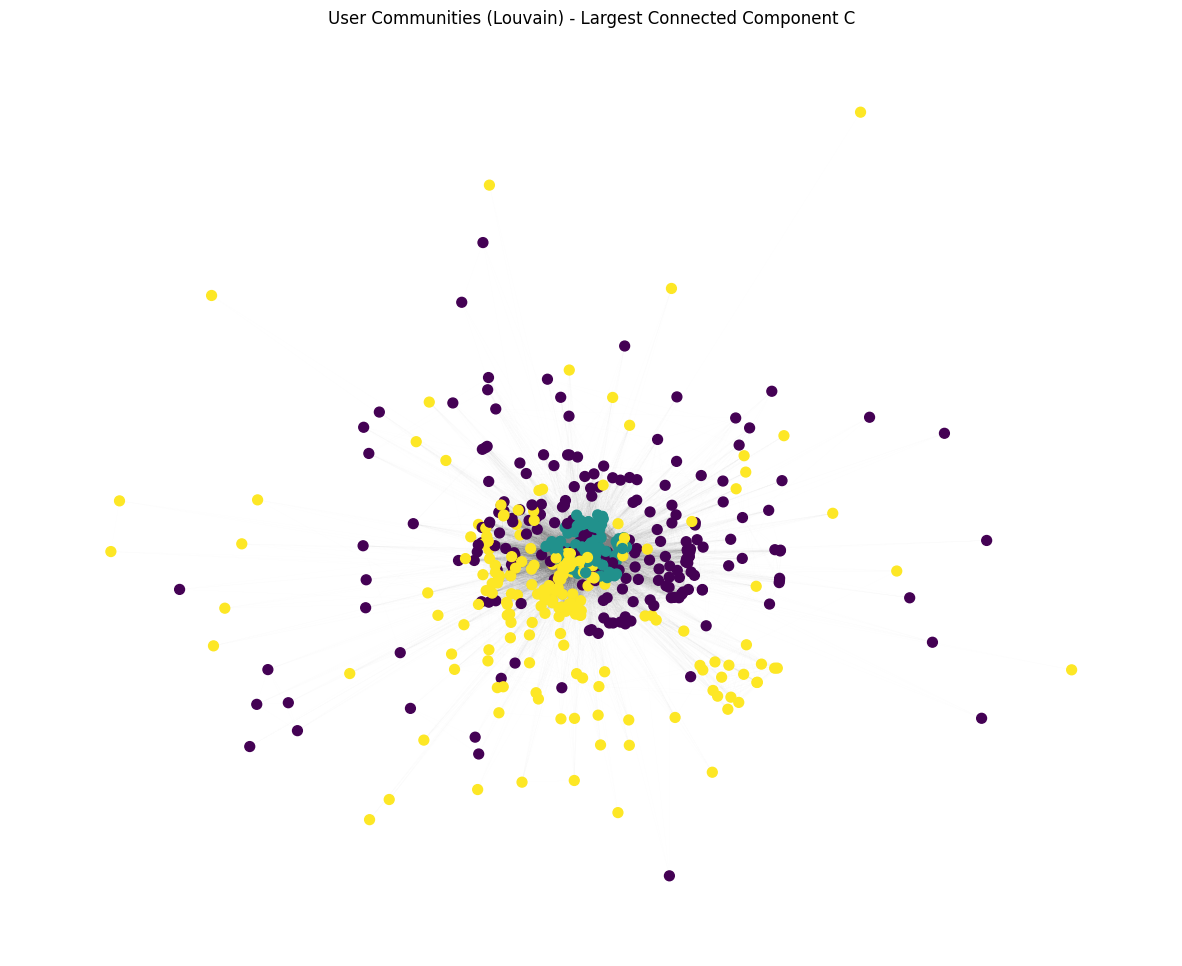

In [79]:

print(f"\nNumber of nodes in colombo: {iden_iden_G.number_of_nodes()}")
print(f"Number of edges in colombo: {iden_iden_G.number_of_edges()}")

# visualize the largest connected component ---
if iden_iden_G.number_of_edges() > 0:
    # Get all connected components
    components = list(nx.connected_components(iden_iden_G))
    
    # Sort (descending)
    largest_component_nodes = max(components, key=len)
    
    # Create a subgraph containing only the largest component
    subgraph_to_plot = iden_iden_G.subgraph(largest_component_nodes)
    
    print(f"Size of largest connected component: {subgraph_to_plot.number_of_nodes()} nodes")
    print(f"Number of edges in largest connected component: {subgraph_to_plot.number_of_edges()}")

    # Run Louvain on  subgraph
    partition_subgraph = community_louvain.best_partition(subgraph_to_plot, weight='weight')
    print(f"Louvain partition found {max(partition_subgraph.values()) + 1} communities in the largest component.")

    # Get positions for the subgraph nodes
    pos_subgraph = nx.spring_layout(subgraph_to_plot, seed=42)

    # Get the number of communities for the colormap (from the subgraph's partition)
    num_communities_subgraph = max(partition_subgraph.values()) + 1
    cmap_subgraph = cm.get_cmap('viridis', num_communities_subgraph)

    plt.figure(figsize=(15, 12)) # Increase figure size for more detail
    
    # Draw nodes for the subgraph
    nx.draw_networkx_nodes(subgraph_to_plot, pos_subgraph, node_size=50, # Slightly smaller nodes
                           node_color=list(partition_subgraph.values()), cmap=cmap_subgraph)
    
    # Draw edges for the subgraph
    # Experiment with alpha and width. For 32k edges, they might still be a blob.
    # A very low alpha (e.g., 0.05 or even lower) can sometimes make it look like a density map.
    nx.draw_networkx_edges(subgraph_to_plot, pos_subgraph,
                           alpha=0.05,        # Very low alpha for dense graphs
                           edge_color='gray', # Consistent color
                           width=0.1)         # Very thin edges

    plt.axis('off')
    plt.title("User Communities (Louvain) - Largest Connected Component C")
    plt.show()
else:
    print("Cannot visualize: colombo has no edges after projection.")

## Local user vs Non Local users
-- need to check it differently.

In [64]:
local_user_ids = set(dfall['user_id'].unique())
print("Unique User IDs (Observer/Creator IDs):")
#print(local_user_ids)
print(f"\nTotal unique users found: {len(local_user_ids)}")

Unique User IDs (Observer/Creator IDs):

Total unique users found: 717


In [68]:
nodes_df['is_local'] = nodes_df['node'].apply(lambda x: int(x[1:]) in local_user_ids)

In [69]:
def classify_user(user_id):
    uid = int(user_id[1:])
    return 'local' if uid in local_user_ids else 'non-local'

nodes_df['location_role'] = nodes_df['node'].apply(classify_user)


In [70]:
nodes_df

,node,attributes,type,is_local,location_role
0,I28,{'bipartite': 'action'},identifier,False,non-local
1,C2770057,{'bipartite': 'observation'},observer,True,local
2,I305,{'bipartite': 'action'},identifier,False,non-local
3,C8828,{'bipartite': 'observation'},observer,True,local
4,C2742819,{'bipartite': 'observation'},observer,True,local
...,...,...,...,...,...
946,I7699943,{'bipartite': 'action'},identifier,True,local
947,I7846972,{'bipartite': 'action'},identifier,False,non-local
948,I7861044,{'bipartite': 'action'},identifier,False,non-local
949,I7973031,{'bipartite': 'action'},identifier,False,non-local
